## Packages and env setup

In [1]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

In [2]:
# pip install transformers==4.37.1

In [3]:
# pip install datasets

In [4]:
# ps aux | grep python

In [5]:
# ps aux | grep python

In [6]:
# nvidia-smi

## Constants

In [7]:
model_name = 'gpt2'
dataset_name = 'tatsu-lab/alpaca'

In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer

## Tokenizer and Model

In [9]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

/venv/main/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Workaround with Tokens

In [10]:
text = 'hello, i\'m wimukthi'
tokens = tokenizer(text)
print(tokens)

{'input_ids': [31373, 11, 1312, 1101, 266, 320, 2724, 400, 72], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [11]:
# print(tokenizer.decode(tokens))

In [12]:
texts = ['hello, i\'m wimukthi', 'i love coding', 'living in Australia']
tokens_obj = tokenizer(texts)
print(tokens_obj)

{'input_ids': [[31373, 11, 1312, 1101, 266, 320, 2724, 400, 72], [72, 1842, 19617], [19950, 287, 4505]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1], [1, 1, 1]]}


In [13]:
for t in tokens_obj['input_ids']:
  print(tokenizer.decode(t))

hello, i'm wimukthi
i love coding
living in Australia


## Load Dataset

In [14]:
from datasets import load_dataset

In [ ]:
dataset = load_dataset(dataset_name)
split = dataset["train"].shuffle(seed=42).select(range(5000)).train_test_split(test_size=0.2)

train_dataset = split["train"]
val_dataset = split["test"]

In [16]:
split

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 49401
    })
    test: Dataset({
        features: ['instruction', 'input', 'output', 'text'],
        num_rows: 2601
    })
})

In [17]:
train_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 49401
})

In [18]:
val_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 2601
})

## Preprocess

In [19]:
def preprocess(example):
    if example['input'].strip() != "":
        prompt = f"Instruction: {example['instruction']}\nInput: {example['input']}\nAnswer:"
    else:
        prompt = f"Instruction: {example['instruction']}\nAnswer:"
    labels = example['output']
    return {"prompt": prompt, "labels": labels}

In [20]:
# ds_train, ds_val = ds['train'], ds['validation']

In [21]:
ds_train = train_dataset.map(preprocess)
ds_val = val_dataset.map(preprocess)

Map:   0%|          | 0/49401 [00:00<?, ? examples/s]

Map:   0%|          | 0/2601 [00:00<?, ? examples/s]

In [22]:
ds_train[:10]

{'instruction': ['Explain why carbon dioxide is a major contributor to climate change.',
  'Generate a list of rules to follow in a school classroom:',
  'Create a marketing slogan that conveys customer satisfaction.',
  'Replace the underlined phrase in the sentence with a suitable phrase.',
  'What species of butterfly is the Philippine foliage?',
  'based on the given type of food, suggest a recipe.',
  'Replace the underlined words with more eloquent words.',
  'Name two key components for successful project management.',
  'Generate a unique username for a platform signup',
  'Compose a tweet on the given topic.'],
 'input': ['',
  '',
  '',
  'They had incredible excited to go on the trip.',
  '',
  'Vegan',
  'In life, you have to face many hardships and it is important that you keep going.',
  '',
  '',
  'The power of technology'],
 'output': ["Carbon dioxide is a major contributor to climate change because it is a greenhouse gas that traps heat in the Earth's atmosphere. Carb

## Tokenization

In [51]:
def tokenize(batch):
    # Ensure inputs are lists of strings
    prompts = batch["prompt"]
    labels = batch["labels"]

    encodings = tokenizer(
        prompts,
        truncation=True,
        padding="max_length",
        max_length=512
    )
    
    label_encodings = tokenizer(
        labels,
        truncation=True,
        padding="max_length",
        max_length=128
    )
    
    # Assign label input_ids
    encodings["labels"] = label_encodings["input_ids"]
    
    return encodings

In [52]:
ds_train.column_names

['instruction', 'input', 'output', 'text', 'prompt', 'labels']

In [80]:
# tokenized_ds = ds_train.map(tokenize, batched=True, batch_size=512, remove_columns=['instruction', 'input', 'output', 'text', 'prompt', 'labels'])


train_dataset_tokenized = ds_train.map(
    tokenize,
    batched=True,
    batch_size=64,  # smaller batch size for map to avoid memory issues
    remove_columns=ds_train.column_names
)

val_dataset_tokenized = ds_val.map(
    tokenize,
    batched=True,
    batch_size=64,
    remove_columns=ds_val.column_names
)

Map:   0%|          | 0/49401 [00:00<?, ? examples/s]

Map:   0%|          | 0/2601 [00:00<?, ? examples/s]

In [81]:
# tokenized_ds

In [82]:
train_dataset_tokenized.set_format(type='torch')
val_dataset_tokenized.set_format(type='torch')

In [83]:
# map_kwargs = {
#     'batched': True,
#     'batch_size': 512,
#     'remove_columns': ['idx', 'sentence', 'label']
# }
# tokenized_dataset_train = ds_train.map(tokenize, **map_kwargs)
# tokenized_dataset_val = ds_val.map(tokenize, **map_kwargs)

In [84]:
# tokenized_dataset_train[:4]

In [85]:
# for i, j in enumerate(tokenized_dataset_train[:4]['input_ids']):
#   print(f'{i+1}: {tokenizer.decode(j)}')

In [86]:
# print(len(tokenized_dataset_train), len(tokenized_dataset_val))

In [87]:
# tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 5)
# tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 5)

In [88]:
# print(len(tokenized_dataset_train), len(tokenized_dataset_val))

In [89]:
# tokenized_dataset_train.set_format(type='torch')
# tokenized_dataset_val.set_format(type='torch')

In [90]:
# tokenized_dataset_train[:5]

In [91]:
# print(tokenizer.pad_token)

In [92]:
print(train_dataset_tokenized[0])

{'labels': tensor([ 9914,  4189, 17556,   318,   257,  1688, 18920,   284,  4258,  1487,
          780,   340,   318,   257, 16325,  3623,   326, 20348,  4894,   287,
          262,  3668,   338,  8137,    13, 23699, 17556,   318,  2716,   618,
        12584, 18017,   884,   355,  5655,    11,  3056,    11,   290,  3288,
         3623,   389, 11544,    13,  1081,   262, 10368,   286,  6588, 17556,
          287,   262,  8137,  5732,    11,   517,  4894,   318, 13640,    11,
         3756,   284,  2440, 10101,   319,   262,  3668,   338,  4417,    13,
          383,  3220,  5951,  5983,   284,   517,  3257,  6193,  2995,    11,
         7396,  5417,  2974,    11,   290,   281,  4045, 35635,   286,   262,
         3668,   338,  4258,  1080,    13, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 502

## Collator

In [93]:
from transformers import DataCollatorForLanguageModeling
from torch.utils.data import DataLoader

In [94]:
tokenizer.pad_token = tokenizer.eos_token

In [95]:
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

dataloader_param = {
    'batch_size': 8,
    'collate_fn': data_collator,
    'shuffle': True
}
train_dataloader = DataLoader(train_dataset_tokenized, **dataloader_param)
val_dataloader = DataLoader(val_dataset_tokenized, **dataloader_param)

In [96]:
len(train_dataloader)

6176

In [97]:
# batch = next(iter(train_dataloader))
# print(batch.keys())

In [98]:
# batch['input_ids'].shape

In [99]:
# batch['input_ids'][0]

In [100]:
# batch['labels'][0]

In [101]:
# batch['attention_mask'][0]

## Optimizer

In [102]:
import torch

In [103]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [104]:
# def validate(epoch):
#   model.eval()
#   total_loss = 0.0
#   for i, batch in enumerate(val_dataloader):
#     batch = {k: v.to(device) for k, v in batch.items()}
#     optimizer.zero_grad()
#     with torch.cuda.amp.autocast():
#       outputs = model(**batch)
#       loss = outputs.loss
#       total_loss += loss.item()
#   print(f'validation loss at epoch {epoch}: {total_loss/len(val_dataloader)}')

In [105]:
len(train_dataloader)

6176

## Training

In [107]:
num_epochs = 1
train_losses = []
val_losses = []


model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0.0
    for i, batch in enumerate(train_dataloader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        print("loss:", loss.item())
        if i % 100 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Train Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1} completed. Avg Train Loss: {avg_train_loss:.4f}")

    # --------------------------
    # Validation
    # --------------------------
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss = outputs.loss
            total_val_loss += val_loss.item()
    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1} completed. Avg Validation Loss: {avg_val_loss:.4f}")

loss: 2.1481447219848633
Epoch 1, Step 0, Train Loss: 2.1481
loss: 2.4646239280700684
loss: 2.6501317024230957
loss: 2.692439556121826
loss: 2.5513722896575928
loss: 2.3359267711639404
loss: 2.3621182441711426
loss: 2.3888916969299316
loss: 2.3866426944732666
loss: 2.1398630142211914
loss: 2.6922574043273926
loss: 2.4903359413146973
loss: 2.2973902225494385
loss: 2.4280359745025635
loss: 2.258727788925171
loss: 2.241131067276001
loss: 2.344496250152588
loss: 2.1457860469818115
loss: 2.099463939666748
loss: 2.1812942028045654
loss: 2.6113150119781494
loss: 2.3427019119262695
loss: 2.561553955078125
loss: 2.5358164310455322
loss: 2.8689517974853516
loss: 3.1139514446258545
loss: 2.030325174331665
loss: 2.2010653018951416
loss: 2.8297109603881836
loss: 2.5899808406829834
loss: 2.4704010486602783
loss: 2.461550712585449
loss: 2.293806552886963
loss: 2.332425594329834
loss: 2.2643909454345703
loss: 2.2466824054718018
loss: 2.3934035301208496
loss: 2.310304880142212
loss: 2.478332757949829
l

In [111]:
print(train_losses, val_losses)

[2.07268225697926] [1.9607955034525117]


## Visualization

In [118]:
import matplotlib.pyplot as plt

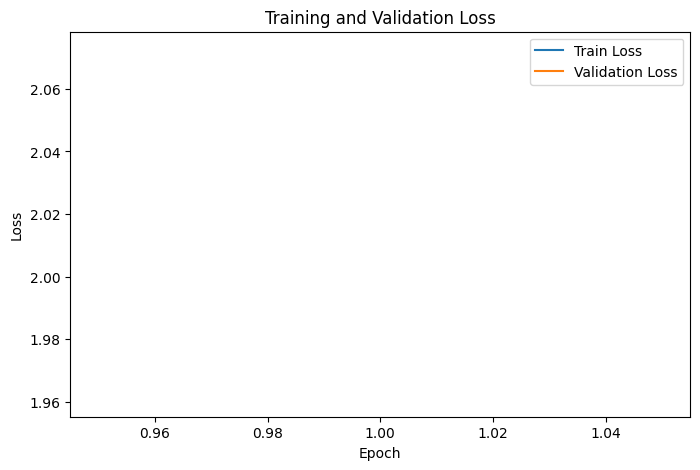

In [121]:
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## Save Model

In [122]:
saving_format = f'{model_name.split('/')[-1]}-{dataset_name.split('/')[-1]}'

In [123]:
model.save_pretrained(f'/sft_model-{saving_format}')

In [124]:
tokenizer.save_pretrained(f'/sft_model-{saving_format}')

('/sft_model-gpt2-alpaca/tokenizer_config.json',
 '/sft_model-gpt2-alpaca/special_tokens_map.json',
 '/sft_model-gpt2-alpaca/vocab.json',
 '/sft_model-gpt2-alpaca/merges.txt',
 '/sft_model-gpt2-alpaca/added_tokens.json',
 '/sft_model-gpt2-alpaca/tokenizer.json')

## Evaluate

In [125]:
model.eval()
prompt = 'Instruction: Summarizing the following text. \nInput: Machine learning models require a lot of data and resources to perform well.\nAnswer:'
input = tokenizer(prompt, return_tensors='pt').to(device)
output = model.generate(**input, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Instruction: Summarizing the following text. 
Input: Machine learning models require a lot of data and resources to perform well.
Answer: Machine learning models are often used to classify data into categories such as sentiment, sentiment analysis, and sentiment analysis.
Answer: Machine learning models are often used to classify data into categories such as sentiment, sentiment analysis, and sentiment analysis.
Answer:


In [126]:
model.eval()
prompt = 'Instruction: Explain. \nInput: What is machine learning.\nAnswer:'
input = tokenizer(prompt, return_tensors='pt').to(device)
output = model.generate(**input, max_new_tokens=50)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Instruction: Explain. 
Input: What is machine learning.
Answer: Machine learning is a field of artificial intelligence that uses machine learning to classify and classify text into categories such as text, images, and videos.
Answer: Text classification is a process of analyzing text to identify and classify it into categories such as text,


In [ ]:
model.from_pretrained(f'/sft_model-{saving_format}')